In [1]:
import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3

load_dotenv(override=True)

open_ai_key = os.getenv("OPENAI_API_KEY")
if not open_ai_key:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")


In [2]:
MODEL = "gpt-4o-mini"
openai = OpenAI()
DB = "prices.db"

In [3]:
system_message = """You are a helpful assistant for an Aieline company called FlightAI.
Give short, courteous answers to questions about flight prices and availability.
Always be accurate. If you don't know the answer, say "I don't know" instead of making up an answer.
You have access to a database of flight prices and availability."""

In [6]:
def get_ticket_price(city):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM ticket_prices WHERE city = ?', (city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [7]:
get_ticket_price("Paris")

DATABASE TOOL CALLED: Getting price for Paris


'Ticket price to Paris is $$899'

In [8]:
price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}

tools = [{"type": "function", "function": price_function}]
tools

[{'type': 'function',
  'function': {'name': 'get_ticket_price',
   'description': 'Get the price of a return ticket to the destination city.',
   'parameters': {'type': 'object',
    'properties': {'destination_city': {'type': 'string',
      'description': 'The city that the customer wants to travel to'}},
    'required': ['destination_city'],
    'additionalProperties': False}}}]

In [9]:

def chat(message, history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages)
    return response.choices[0].message.content

gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [10]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
    return response.choices[0].message.content

In [12]:
def handle_tool_calls(message):
    response = []
    for tool_call in message.tool_calls:
        if tool_call.name == "get_ticket_price":
            city = tool_call.arguments.get("destination_city")
            price_details = get_ticket_price(city)
            response.append({"role": "tool", "name": tool_call.name, "tool_call_id": tool_call.id, "content": price_details})
    return response

In [13]:
gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "d:\2026 AI Training\ed\my_project\ai_enginnering_handbook\.venv\Lib\site-packages\gradio\queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\2026 AI Training\ed\my_project\ai_enginnering_handbook\.venv\Lib\site-packages\gradio\route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\2026 AI Training\ed\my_project\ai_enginnering_handbook\.venv\Lib\site-packages\gradio\blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\2026 AI Training\ed\my_project\ai_enginnering_handbook\.venv\Lib\site-packages\gradio\blocks.py", line 1696, in call_function
    prediction = await fn(*processed_input)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\2026 AI Training\ed\my_project\ai

# More about Gradio
## Image Genetation

In [14]:
import base64
from io import BytesIO
from PIL import Image

In [15]:
def artist(city):
    image_response = openai.images.generate(
    model = "gpt-image-1-mini",
    prompt = f"An artistic representation of {city} in a futuristic style, vibrant colors, and detailed architecture.",
    size = "1024x1024",
    n=1
    )
    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    image = Image.open(BytesIO(image_data))
    return image

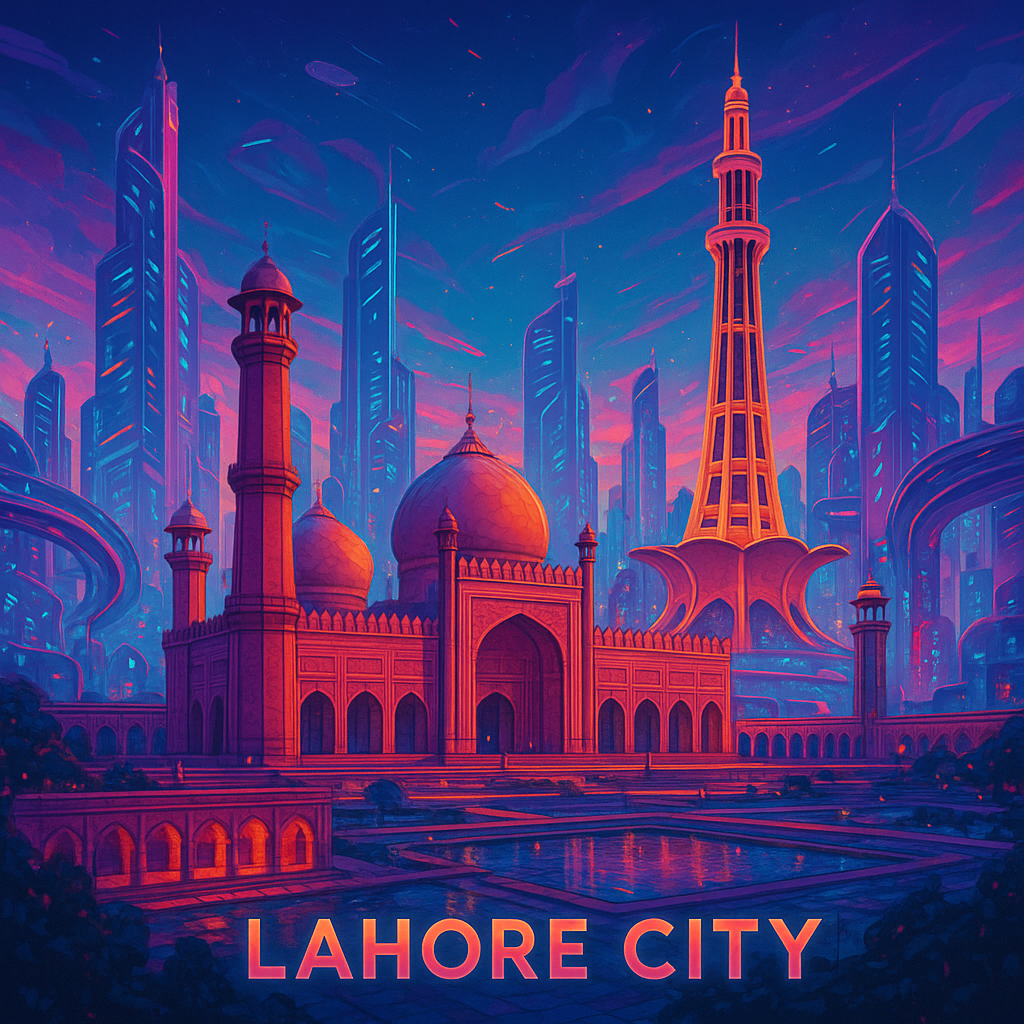

In [16]:
image = artist("Lahore City")
display(image)

In [17]:
def talker(message):
    response = openai.audio.speech.create(
        model="gpt-4o-mini-tts",
        voice="coral",
        input=message
    )
    
    return response.content

In [18]:
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
    cities =[]
    image = None
    
    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
        
    reply = response.choices[0].message.content
    history.append({"role": "assistant", "content": reply})
    
    voice = talker(reply)
    
    if cities:
        image = artist(cities[0])
        
    return history, voice, image

In [21]:
def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

In [20]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("ed", "bananas"))

C:\Users\madil\AppData\Local\Temp\ipykernel_11092\856743599.py:10: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(height=500, type="messages")


* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "d:\2026 AI Training\ed\my_project\ai_enginnering_handbook\.venv\Lib\site-packages\gradio\queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\2026 AI Training\ed\my_project\ai_enginnering_handbook\.venv\Lib\site-packages\gradio\route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\2026 AI Training\ed\my_project\ai_enginnering_handbook\.venv\Lib\site-packages\gradio\blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\2026 AI Training\ed\my_project\ai_enginnering_handbook\.venv\Lib\site-packages\gradio\blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  